Plotting System Metrics

1. Plotting TPS metrics...


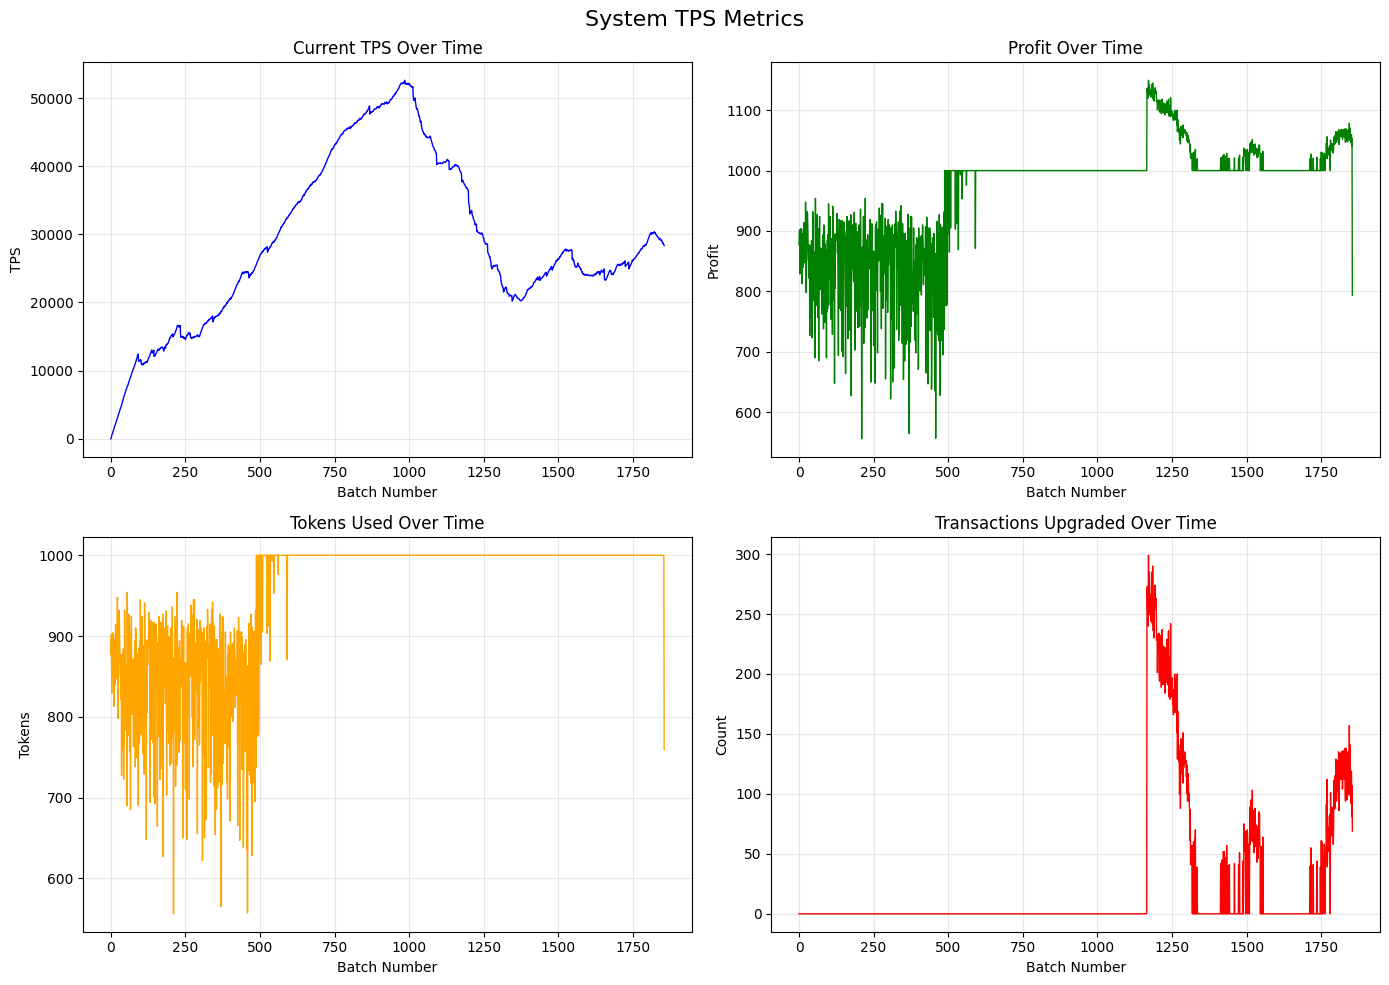


2. Plotting Backlog...


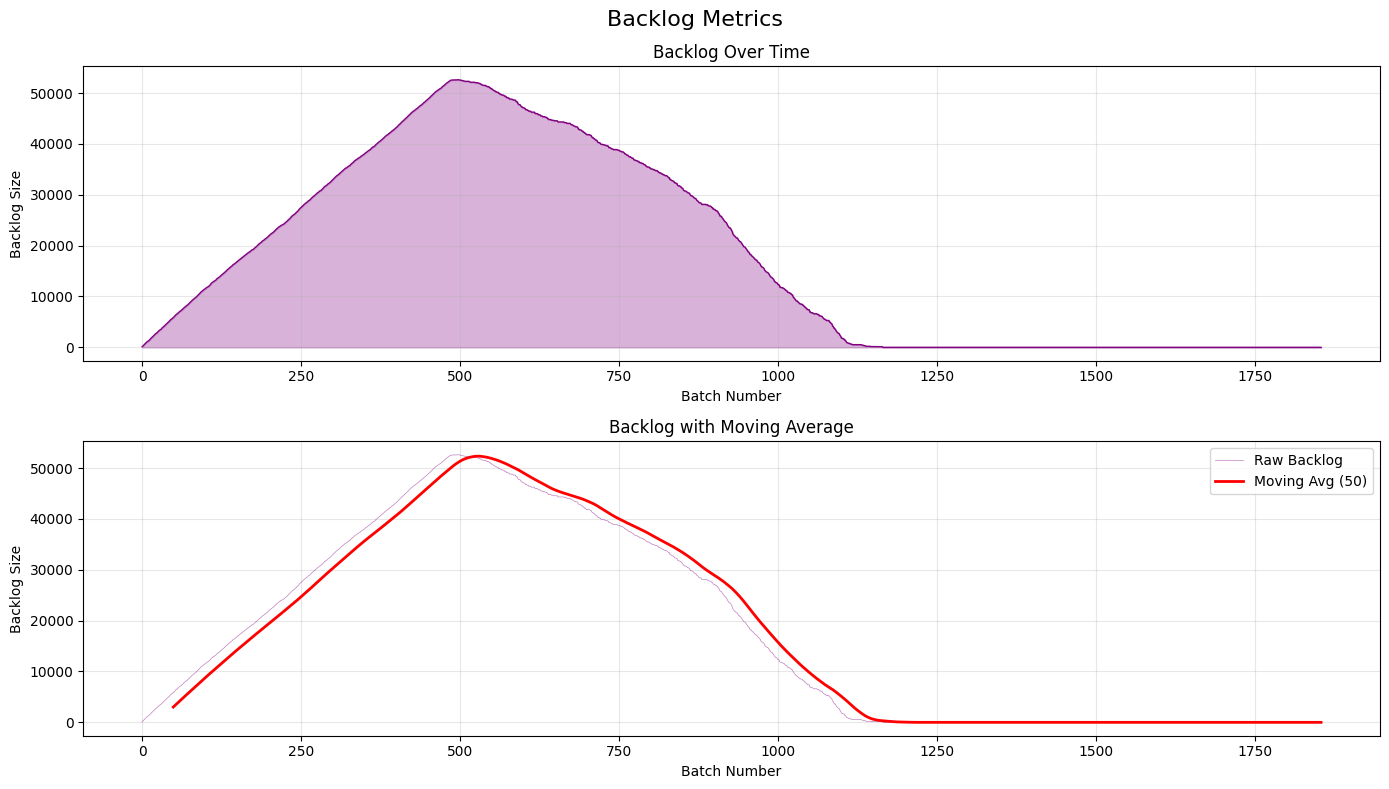


3. Plotting WriteConcern Frequency...


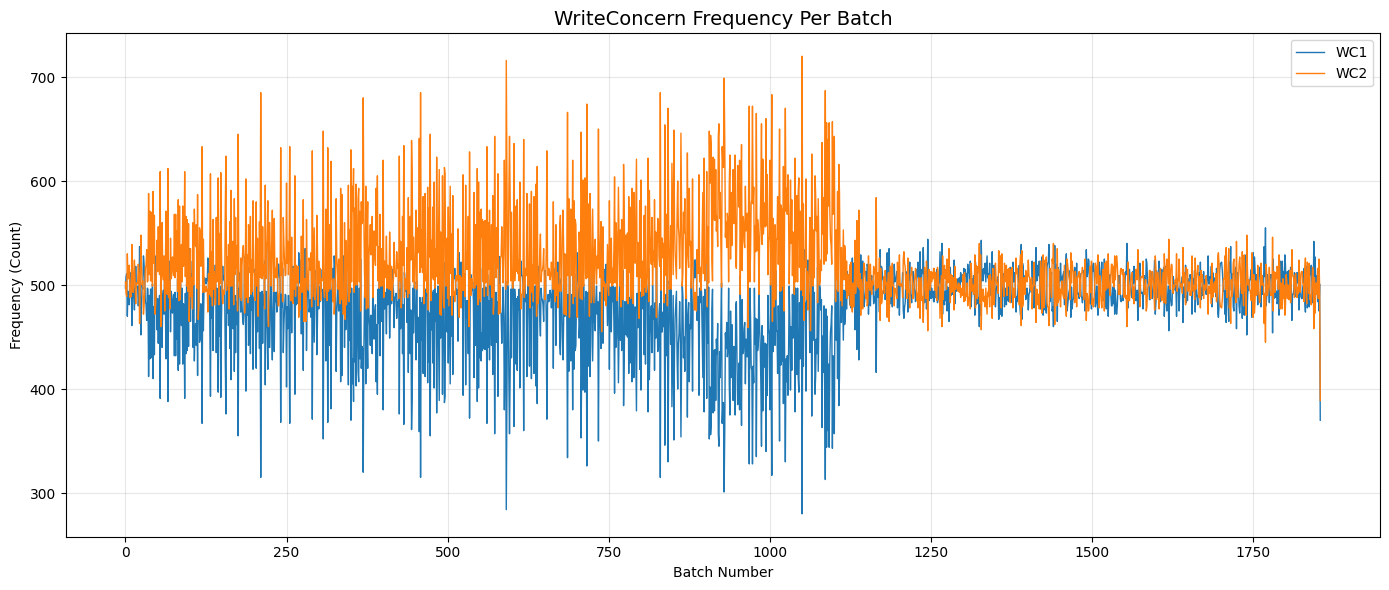


4. Plotting WriteConcern TPS...


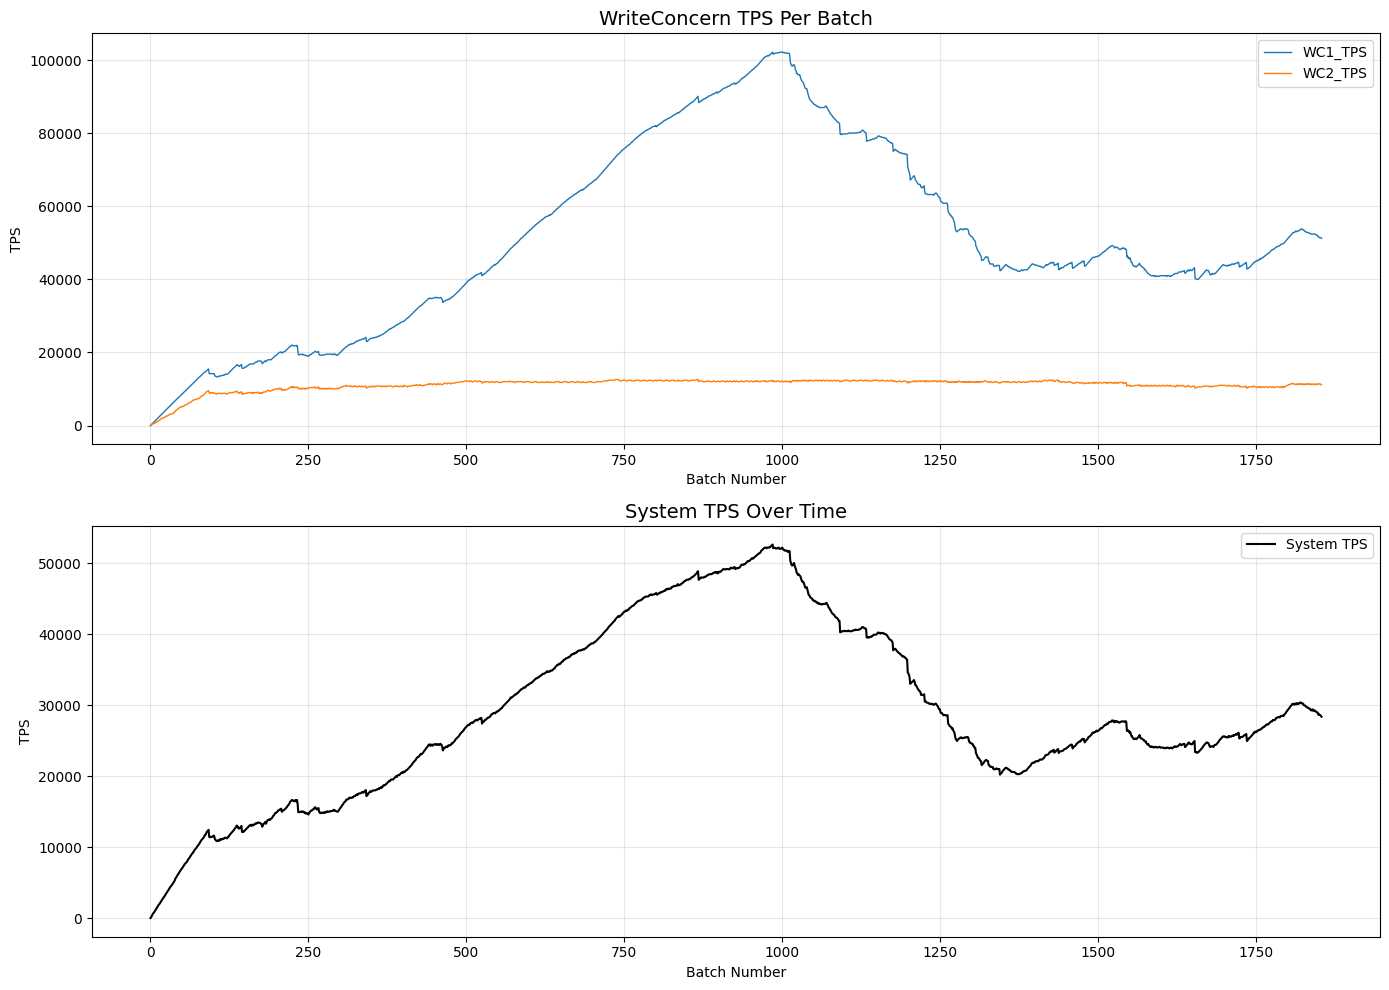


5. Plotting Combined Dashboard...


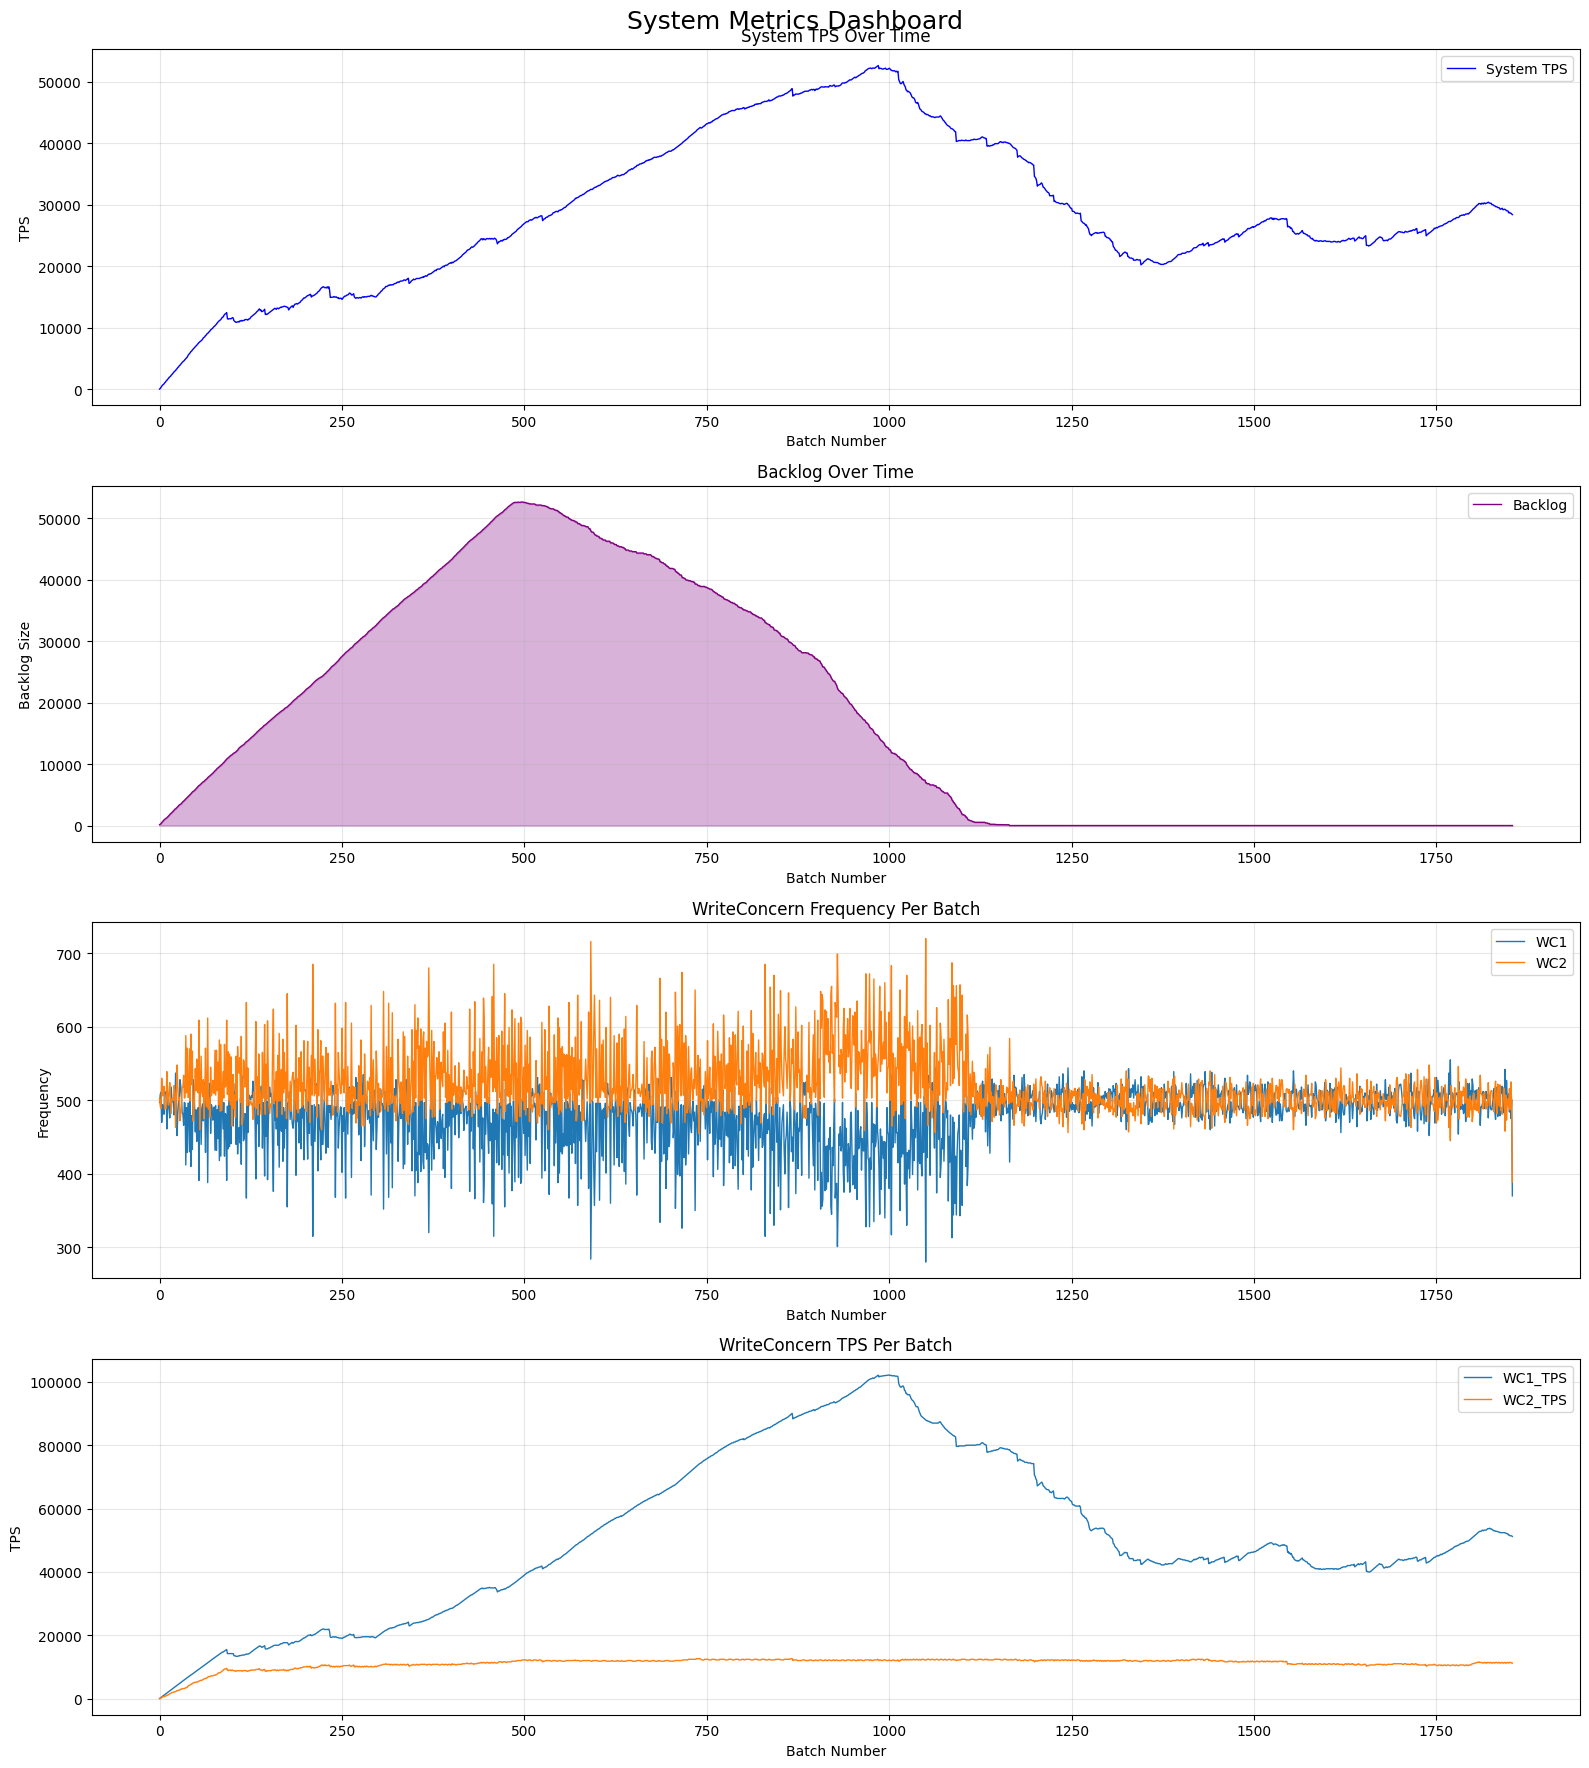


6. Plotting Stacked Area Chart...


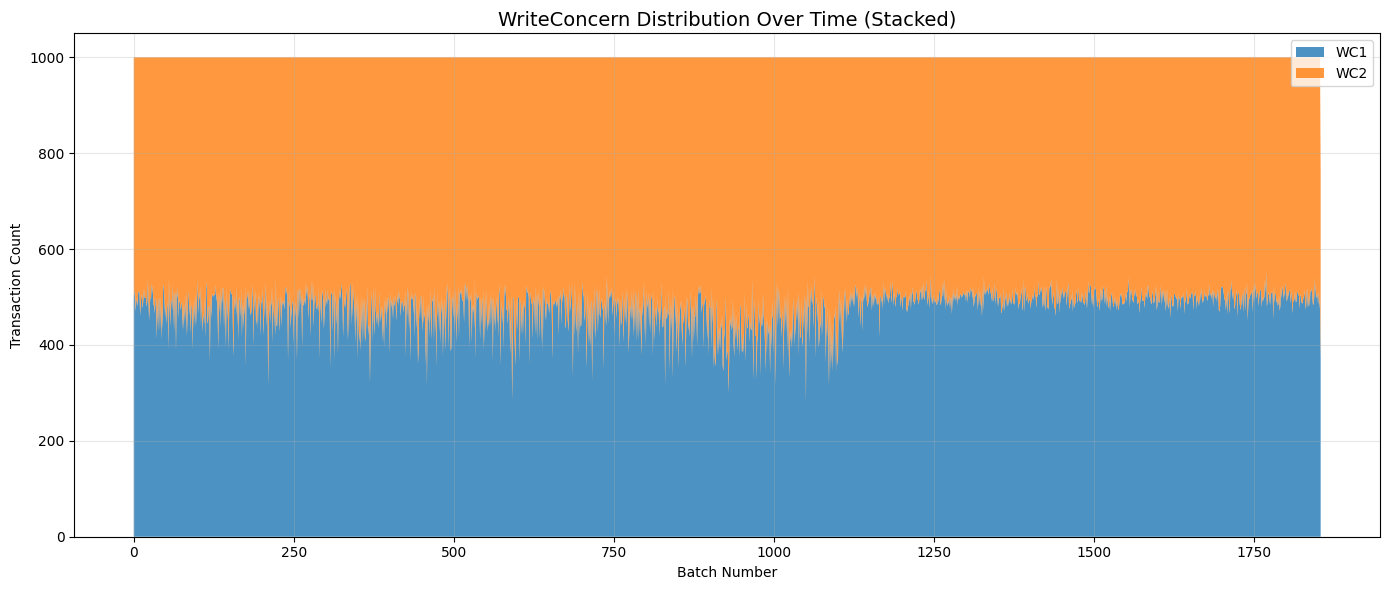


All plots generated successfully!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

def plot_tps():
    """Plot system TPS metrics from tps.csv"""
    filepath = os.path.join(CSV_DIR, "tps.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('System TPS Metrics', fontsize=16)
    
    # Plot Current TPS
    axes[0, 0].plot(df.index, df['CurrentTPS'], color='blue', linewidth=1)
    axes[0, 0].set_title('Current TPS Over Time')
    axes[0, 0].set_xlabel('Batch Number')
    axes[0, 0].set_ylabel('TPS')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot Profit
    axes[0, 1].plot(df.index, df['Profit'], color='green', linewidth=1)
    axes[0, 1].set_title('Profit Over Time')
    axes[0, 1].set_xlabel('Batch Number')
    axes[0, 1].set_ylabel('Profit')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot Tokens Used
    axes[1, 0].plot(df.index, df['TokensUsed'], color='orange', linewidth=1)
    axes[1, 0].set_title('Tokens Used Over Time')
    axes[1, 0].set_xlabel('Batch Number')
    axes[1, 0].set_ylabel('Tokens')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot Transactions Upgraded
    axes[1, 1].plot(df.index, df['TransactionsUpgraded'], color='red', linewidth=1)
    axes[1, 1].set_title('Transactions Upgraded Over Time')
    axes[1, 1].set_xlabel('Batch Number')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_backlog():
    """Plot backlog metrics from backlog.csv"""
    filepath = os.path.join(CSV_DIR, "backlog.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Backlog Metrics', fontsize=16)
    
    # Plot Backlog over time
    axes[0].plot(df.index, df['Backlog'], color='purple', linewidth=1)
    axes[0].set_title('Backlog Over Time')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('Backlog Size')
    axes[0].grid(True, alpha=0.3)
    axes[0].fill_between(df.index, df['Backlog'], alpha=0.3, color='purple')
    
    # Plot Backlog with rolling average
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['Backlog_MA'] = df['Backlog'].rolling(window=window_size).mean()
        axes[1].plot(df.index, df['Backlog'], color='purple', linewidth=0.5, alpha=0.5, label='Raw Backlog')
        axes[1].plot(df.index, df['Backlog_MA'], color='red', linewidth=2, label=f'Moving Avg ({window_size})')
        axes[1].legend()
    else:
        axes[1].plot(df.index, df['Backlog'], color='purple', linewidth=1)
    axes[1].set_title('Backlog with Moving Average')
    axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Backlog Size')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_writeconcern_frequency():
    """Plot writeConcern frequency from writeconcern_frequency.csv"""
    filepath = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    # Get WC columns (exclude Timestamp and TotalInBatch)
    wc_columns = [col for col in df.columns if col.startswith('WC')]
    
    plt.figure(figsize=(14, 6))
    
    for col in wc_columns:
        plt.plot(df.index, df[col], label=col, linewidth=1)
    
    plt.title('WriteConcern Frequency Per Batch', fontsize=14)
    plt.xlabel('Batch Number')
    plt.ylabel('Frequency (Count)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_writeconcern_tps():
    """Plot writeConcern TPS from writeconcern_tps.csv"""
    filepath = os.path.join(CSV_DIR, "writeconcern_tps.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    # Get WC TPS columns (exclude Timestamp and SystemTPS)
    wc_tps_columns = [col for col in df.columns if col.startswith('WC') and col.endswith('_TPS')]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot individual WC TPS
    for col in wc_tps_columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1)
    
    axes[0].set_title('WriteConcern TPS Per Batch', fontsize=14)
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Plot System TPS for comparison
    if 'SystemTPS' in df.columns:
        axes[1].plot(df.index, df['SystemTPS'], color='black', linewidth=1.5, label='System TPS')
        axes[1].set_title('System TPS Over Time', fontsize=14)
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('TPS')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_combined_view():
    """Create a combined dashboard view"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle('System Metrics Dashboard', fontsize=18)
    
    # 1. TPS from tps.csv
    tps_file = os.path.join(CSV_DIR, "tps.csv")
    if os.path.exists(tps_file):
        df_tps = pd.read_csv(tps_file)
        axes[0].plot(df_tps.index, df_tps['CurrentTPS'], color='blue', linewidth=1, label='System TPS')
        axes[0].set_title('System TPS Over Time')
        axes[0].set_xlabel('Batch Number')
        axes[0].set_ylabel('TPS')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # 2. Backlog
    backlog_file = os.path.join(CSV_DIR, "backlog.csv")
    if os.path.exists(backlog_file):
        df_backlog = pd.read_csv(backlog_file)
        axes[1].plot(df_backlog.index, df_backlog['Backlog'], color='purple', linewidth=1, label='Backlog')
        axes[1].fill_between(df_backlog.index, df_backlog['Backlog'], alpha=0.3, color='purple')
        axes[1].set_title('Backlog Over Time')
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('Backlog Size')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    # 3. WriteConcern Frequency
    freq_file = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if os.path.exists(freq_file):
        df_freq = pd.read_csv(freq_file)
        wc_columns = [col for col in df_freq.columns if col.startswith('WC')]
        for col in wc_columns:
            axes[2].plot(df_freq.index, df_freq[col], label=col, linewidth=1)
        axes[2].set_title('WriteConcern Frequency Per Batch')
        axes[2].set_xlabel('Batch Number')
        axes[2].set_ylabel('Frequency')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, alpha=0.3)
    
    # 4. WriteConcern TPS
    wc_tps_file = os.path.join(CSV_DIR, "writeconcern_tps.csv")
    if os.path.exists(wc_tps_file):
        df_wc_tps = pd.read_csv(wc_tps_file)
        wc_tps_columns = [col for col in df_wc_tps.columns if col.startswith('WC') and col.endswith('_TPS')]
        for col in wc_tps_columns:
            axes[3].plot(df_wc_tps.index, df_wc_tps[col], label=col, linewidth=1)
        axes[3].set_title('WriteConcern TPS Per Batch')
        axes[3].set_xlabel('Batch Number')
        axes[3].set_ylabel('TPS')
        axes[3].legend(loc='upper right')
        axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_stacked_area_frequency():
    """Plot stacked area chart for writeConcern frequency distribution"""
    filepath = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    wc_columns = [col for col in df.columns if col.startswith('WC')]
    
    plt.figure(figsize=(14, 6))
    plt.stackplot(df.index, [df[col] for col in wc_columns], labels=wc_columns, alpha=0.8)
    plt.title('WriteConcern Distribution Over Time (Stacked)', fontsize=14)
    plt.xlabel('Batch Number')
    plt.ylabel('Transaction Count')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("=" * 50)
    print("Plotting System Metrics")
    print("=" * 50)
    
    # Plot individual charts
    print("\n1. Plotting TPS metrics...")
    plot_tps()
    
    print("\n2. Plotting Backlog...")
    plot_backlog()
    
    print("\n3. Plotting WriteConcern Frequency...")
    plot_writeconcern_frequency()
    
    print("\n4. Plotting WriteConcern TPS...")
    plot_writeconcern_tps()
    
    print("\n5. Plotting Combined Dashboard...")
    plot_combined_view()
    
    print("\n6. Plotting Stacked Area Chart...")
    plot_stacked_area_frequency()
    
    print("\n" + "=" * 50)
    print("All plots generated successfully!")
    print("=" * 50)